In [ ]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.stats import norm, t, binom, poisson, expon, chi2, f
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
source
#
# 1) One-Hot Encoding
#    - Description: Creates binary/dummy columns for each category (0/1).
#    - When to use: For nominal categories with no natural order; avoid when
#      cardinality is very high unless you reduce dimensions first.
#
# 2) Label Encoding
#    - Description: Maps categories to integer labels (0,1,2,...).
#    - When to use: For ordinal features or with tree-based models that can
#      handle integer categories; avoid for nominal features with linear models.
#
# 3) Ordinal Encoding
#    - Description: Encodes categories as integers according to a specified order.
#    - When to use: When categories have a meaningful order (e.g., low<med<high).
#
# 4) Frequency / Count Encoding
#    - Description: Replaces categories with their frequency or count in the data.
#    - When to use: Useful for high-cardinality features where one-hot would create
#      too many columns and a compact numeric representation is preferred.
#
# 5) Target / Mean Encoding
#    - Description: Replaces categories with a target-based statistic (e.g., mean).
#    - When to use: Can be powerful for predictive tasks but requires careful
#      handling (smoothing, cross-validation) to prevent target leakage and overfitting.
#
# 6) Binary / Hash / BaseN Encoding
#    - Description: Compact encodings that convert categories to binary/base-N
#      representations or hashed feature indices.
#    - When to use: When reducing dimensionality is important or when handling
#      streaming/unseen categories; hashing trades interpretability for fixed size.
#
# 7) Embedding Representations (deep learning)
#    - Description: Learns dense vector representations for categories using an
#      embedding layer or similar approach.
#    - When to use: For very high-cardinality categorical variables in neural
#      network models where learned representations improve performance.
#
# Practical considerations:
#  - Avoid the dummy variable trap with linear models (drop one dummy column).
#  - Handle unseen categories in production by mapping them to a special value
#    or using encoders that support unknown categories to avoid runtime errors.
#  - Group rare categories into an 'Other' bucket when sample counts are low.
#  - Scale or normalize numeric encodings if the downstream model expects scaled inputs.
#  - Choose simpler encodings for small datasets/models; test target/embedding
#    approaches for large/high-cardinality problems with proper validation.

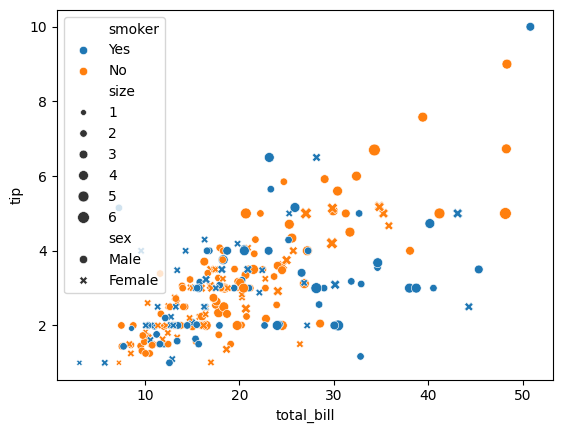

In [328]:
sns.scatterplot(x=df.total_bill, y=df.tip, hue= df.smoker, style=df.sex, size = df['size'])
plt.show()

In [329]:
mat1 = df.corr(numeric_only=True)
mat1


# here all the values are positive so no against relation (up going up and other going down)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

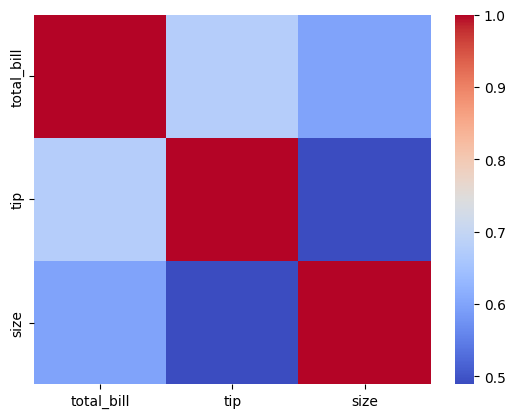

In [330]:
sns.heatmap(mat1, cmap='coolwarm')

In [331]:
# covariance
# coefficient of variant


In [332]:
import numpy as np

In [333]:
x1 = np.array([4,5,3,7,8,9])
x2 = np.array([2,9,7,4,3,6])

In [334]:
np.cov(x1,x2)

array([[ 5.6       , -1.2       ],
       [-1.2       ,  6.96666667]])

In [335]:
np.var(x1, ddof=1)

np.float64(5.6)

In [336]:
np.var(x2,ddof=1)

np.float64(6.966666666666666)

In [337]:
(sum(x1-np.mean(x1))* (x2-np.mean(x2)))/(len(x1)-1)

array([-0.,  0.,  0., -0., -0.,  0.])

In [338]:
(sum(x1-np.mean(x1))*(x2-np.mean(x2)))/(len(x1) -1)

array([-0.,  0.,  0., -0., -0.,  0.])

In [339]:
scipy.stats.pearsonr(x1,x2)

PearsonRResult(statistic=np.float64(-0.19212094618518188), pvalue=np.float64(0.7153642167762257))

In [340]:
-1.2/(np.std(x1,ddof=1)*np.std(x2,ddof=1))

np.float64(-0.19212094618518186)

In [341]:
w1 = [3,8,6,3,6,8,9,7,6]
w2 = [60,65,67,68,71,73,58,73,60]

In [342]:
np.std(w1, ddof=1)

np.float64(2.1081851067789197)

In [343]:
np.std(w2,ddof=1)

np.float64(5.754225500544022)

In [344]:
np.mean(w1)

np.float64(6.222222222222222)

In [345]:
np.mean(w2)

np.float64(66.11111111111111)

In [346]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [347]:
import pandas as pd
import os
os.chdir(r'/Users/proxim/Desktop/CDAC-DBDA-coursework/08.advanced-analytics-stats')
import matplotlib.pyplot as plt

In [348]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'faithful')

In [349]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


In [350]:
erupt = df.eruptions

In [351]:
wait = df.waiting

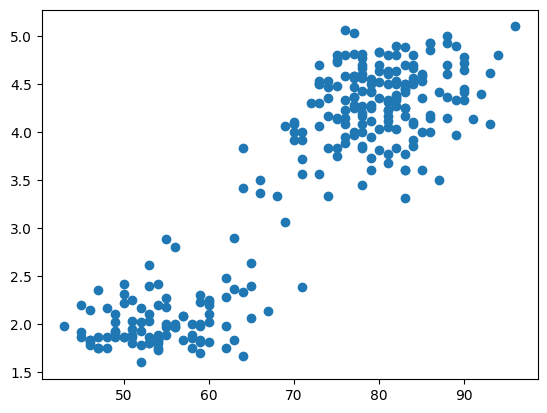

In [352]:
plt.scatter(wait, erupt)
plt.show()

In [353]:
scipy.stats.pearsonr(wait, erupt)

PearsonRResult(statistic=np.float64(0.9008111683218131), pvalue=np.float64(8.129958506617982e-100))

In [354]:
x_train, x_test, y_train, y_test = train_test_split(df.waiting, df.eruptions, random_state=20, test_size = 0.25)

In [355]:
x_train.shape

(204,)

In [356]:
y_train.shape

(204,)

In [357]:
x_test.shape

(68,)

In [358]:
y_test.shape

(68,)

In [359]:
x_train.head()

21     47
1      54
84     73
147    49
148    96
Name: waiting, dtype: int64

In [360]:
# constant term the value of response when the value

In [361]:
x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.OLS(y_train, x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              eruptions   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.798
Method:                 Least Squares   F-statistic:                     804.1
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.34e-72
Time:                        12:52:41   Log-Likelihood:                -153.37
No. Observations:                 204   AIC:                             310.7
Df Residuals:                     202   BIC:                             317.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
waiting        0.0770      0.003     28.357      0.0

In [362]:
mydata = pd.DataFrame([[60,1], [80,1]], columns=['waiting', 'const'])

In [363]:
mydata

,waiting,const
0,60,1
1,80,1


In [364]:
mod1.predict(mydata)

0    2.628886
1    4.168843
dtype: float64

##### multiple linear regression

In [365]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='stackloss')

In [366]:
df.head()

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18


In [367]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'stackloss')
x_train,x_test,y_train,y_test = train_test_split(df.drop('StackLoss',axis=1), df.StackLoss, \
random_state = 20, test_size=0.15)
x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.OLS(y_train,x_train).fit()
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:              StackLoss   R-squared:                       0.910
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     43.81
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           4.66e-07
Time:                        12:52:41   Log-Likelihood:                -43.635
No. Observations:                  17   AIC:                             95.27
Df Residuals:                      13   BIC:                             98.60
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AirFlow        0.6961      0.157      4.441      0.0

In [368]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name='salaries')

In [369]:
my_df = df[['yrs_service', 'gender', 'salary']]

In [370]:
my_df.head()

,yrs_service,gender,salary
0,18,Male,139750
1,16,Male,173200
2,3,Male,79750
3,39,Male,115000
4,41,Male,141500


In [371]:
gen_dummy= pd.get_dummies(my_df.gender, drop_first=True).astype(int)
gen_dummy.head()


,Male
0,1
1,1
2,1
3,1
4,1


In [372]:
my_df = my_df.drop('gender', axis = 1)

In [373]:
my_df = pd.concat([my_df, gen_dummy], axis = 1)

In [374]:
my_df.head()

,yrs_service,salary,Male
0,18,139750,1
1,16,173200,1
2,3,79750,1
3,39,115000,1
4,41,141500,1


In [375]:
np.unique([my_df.Male])

array([0, 1])

In [376]:
np.unique(df['gender'])

array(['Female', 'Male'], dtype=object)

In [377]:
np.unique(df['rank'])

array(['AssocProf', 'AsstProf', 'Prof'], dtype=object)

In [378]:
x_train, x_test, y_train, y_test = train_test_split(my_df.drop('salary', axis = 1), my_df.salary, random_state = 20, test_size = 0.1)
x_train= sm.add_constant(x_train, prepend = False)
mod1 = sm.OLS(y_train, x_train).fit()

In [379]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.129
Model:                            OLS   Adj. R-squared:                  0.125
Method:                 Least Squares   F-statistic:                     26.31
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           2.22e-11
Time:                        12:52:43   Log-Likelihood:                -4165.1
No. Observations:                 357   AIC:                             8336.
Df Residuals:                     354   BIC:                             8348.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service   774.6347    117.519      6.592      

In [380]:
# with reference to female(female events), the (male) will get a salary which is more than 10180 more, because it position
# keeping all the other factors as constant

In [381]:
my_df = df[['yrs_service', 'rank', 'salary']]

In [382]:
x_train, x_test, y_train, y_test = train_test_split(my_df.drop('salary', axis = 1), my_df.salary, random_state = 20, test_size = 0.1)

# Convert rank to dummy variables
rank_train_dummy = pd.get_dummies(x_train['rank'], drop_first=True).astype(int)
x_train = x_train.drop('rank', axis=1)
x_train = pd.concat([x_train, rank_train_dummy], axis=1)

x_train = sm.add_constant(x_train, prepend = False)
mod1 = sm.OLS(y_train, x_train).fit()

In [384]:
print(mod1.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.393
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     76.20
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           5.03e-38
Time:                        12:52:48   Log-Likelihood:                -4100.7
No. Observations:                 357   AIC:                             8209.
Df Residuals:                     353   BIC:                             8225.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
yrs_service  -102.3938    121.964     -0.840      

In [385]:
# H0 third row - > when the rank changes from associate professor to professor this change has no impact to the salary

In [ ]:
# H0 - 
# step 2: decision for null hypothesis
# step 3: effect corresponding row
# step 4:  

In [386]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train,x_test,y_train,y_test=train_test_split(df.drop('StackLoss',axis=1),df.StackLoss,test_size=0.1,random_state=20)
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

KeyError: "['StackLoss'] not found in axis"

In [ ]:
# Different techniques to handle categorical data (summary and examples)
#
# 1) One-Hot Encoding
#    - Creates binary/dummy columns for each category (0/1).
#    - Use when categories are nominal (no natural order).
#    - Beware of high cardinality (many columns); consider
#      dimensionality reduction or other encodings for those cases.
#    - pandas example:
#        pd.get_dummies(df['col'], prefix='col', drop_first=False)
#    - sklearn example (keeps column transformer friendly):
#        from sklearn.preprocessing import OneHotEncoder
#        ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
#
# 2) Label Encoding
#    - Maps categories to integer labels (0,1,2,...).
#    - Use for ordinal features or when you will use tree-based models
#      that can handle integer categories sensibly.
#    - Do NOT use naive label encoding for nominal data with
#      linear models (introduces artificial order).
#    - sklearn example:
#        from sklearn.preprocessing import LabelEncoder
#        le = LabelEncoder(); df['col_enc'] = le.fit_transform(df['col'])
#
# 3) Ordinal Encoding
#    - Similar to label encoding but you explicitly provide the order.
#    - Use when categories have a meaningful order (e.g., low<med<high).
#    - sklearn example:
#        from sklearn.preprocessing import OrdinalEncoder
#        ord = OrdinalEncoder(categories=[['low','med','high']])
#        df['col_ord'] = ord.fit_transform(df[['col']])
#
# 4) Frequency / Count Encoding
#    - Replace each category with its frequency or count in the training data.
#    - Keeps a single numeric column; useful for high-cardinality features.
#    - Example:
#        counts = df['col'].value_counts()
#        df['col_count'] = df['col'].map(counts)
#
# 5) Target / Mean Encoding
#    - Replace categories with the mean (or other statistic) of the target
#      for that category (e.g., mean sales for 'store').
#    - Powerful but prone to target leakage; use smoothing or cross-validation
#      (K-fold) to avoid overfitting.
#
# 6) Binary / Hash / BaseN Encoding
#    - Binary encoding reduces dimensionality by converting categories to binary digits
#      and splitting digits into columns.
#    - Hashing encoding (FeatureHasher) maps categories to a fixed number of columns
#      and can handle streaming/unseen categories but risks collisions.
#
# 7) Embedding Representations (deep learning)
#    - Learn dense vector representations for categories using an embedding layer.
#    - Useful for very high-cardinality categorical variables in neural networks.
#
# Practical considerations:
#  - Drop one dummy column (or use drop_first=True) when using linear models
#    to avoid multicollinearity (dummy variable trap).
#  - Use handle_unknown='ignore' or map unseen categories to a special value
#    when encoding production data to avoid runtime errors.
#  - Combine rare categories (group into 'Other') when a category has very few samples.
#  - Scale / normalize numeric encodings if model expects scaled features.
#  - Prefer simple encodings for small models; try target or embeddings for
#    complex/high-cardinality cases and validate carefully.
#
# Quick examples:
#    # one-hot using pandas
#    df = pd.concat([df, pd.get_dummies(df['city'], prefix='city')], axis=1)
#
#    # frequency encoding
#    df['city_freq'] = df['city'].map(df['city'].value_counts())
#
#    # ordinal encoding with explicit order
#    from sklearn.preprocessing import OrdinalEncoder
#    ord_enc = OrdinalEncoder(categories=[['junior','mid','senior']])
#    df['level_ord'] = ord_enc.fit_transform(df[['level']])
#
# If you'd like, I can add runnable code cells demonstrating each technique
# on a small sample DataFrame and show the resulting transformed columns.

In [396]:
df = pd.DataFrame({'Color':['R','R','B','R','Y','B','Y','R']})

In [397]:
col_one= pd.get_dummies(df.Color,drop_first=True).astype(int)

In [398]:
df = pd.concat([df, col_one], axis=1)

In [403]:
from sklearn.preprocessing import *

In [404]:
le =LabelEncoder()
df['LabelEncoded'] = le.fit_transform(df.Color)

In [405]:
df.head()

,Color,R,Y,LabelEncoded
0,R,1,0,1
1,R,1,0,1
2,B,0,0,0
3,R,1,0,1
4,Y,0,1,2


In [406]:
df = pd.DataFrame({'Colour':['R','R','B','R','Y','B','Y','R']})

# One Hot Encoding
col_ohe = pd.get_dummies(df.Colour, drop_first=True).astype(int)
df = pd.concat([df,col_ohe], axis=1)

# Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['LabelEncoded'] = le.fit_transform(df.Colour)

# Frequency Coding
cts = df.Colour.value_counts().reset_index()
pd.merge(df,cts,on='Colour')

# Target Encoding

df = pd.DataFrame({'City':['M','M','D','B','D','B','M','B','D'], 
                   'Buy' : [1,0,1,1,0,1,0,1,1]})
city_mean = df.groupby('City')['Buy'].mean().reset_index()
pd.merge(df,city_mean,on='City')

,City,Buy_x,Buy_y
0,M,1,0.333333
1,M,0,0.333333
2,D,1,0.666667
3,B,1,1.000000
4,D,0,0.666667
5,B,1,1.000000
6,M,0,0.333333
7,B,1,1.000000
8,D,1,0.666667


In [408]:
from sklearn.preprocessing import OrdinalEncoder
df = pd.DataFrame({'Colour':['R','R','B','R','Y','B','Y','R']})
ord1 = ['Y','B','R']
oe = OrdinalEncoder(categories = [ord1])
df['OrdinalEncoded'] = oe.fit_transform(df[['Colour']])
df

,Colour,OrdinalEncoded
0,R,2.0
1,R,2.0
2,B,1.0
3,R,2.0
4,Y,0.0
5,B,1.0
6,Y,0.0
7,R,2.0


In [416]:
df = pd.read_excel('data/CDAC_DataBook.xlsx', sheet_name = 'stackloss')
x_train,x_test,y_train,y_test=train_test_split(df.drop('StackLoss',axis=1),df.StackLoss,test_size=0.1,random_state=20)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [417]:
df.head()

,AirFlow,WaterTemp,AcidConc,StackLoss
0,80,27,89,42
1,80,27,88,37
2,75,25,90,37
3,62,24,87,28
4,62,22,87,18
